# InterScale Pipeline: Combined model

1. Local Model = GCN
2. Global Model = Self-attention transformer

Data: Visium Breast Cancer (no conditions, all TME) 

In [2]:
import scanpy as sc
import numpy as np
import squidpy as sq

import InterScale as interscale
from InterScale.config import load_config
#from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

# from graph_transformer_long_range_niches.config import load_config
# from graph_transformer_long_range_niches.pp import sliding_window

In [3]:
CFG_PATH_CLAS = "/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/config_files/Visium_breast_cancer/class_graph_Combined_condition.yaml"

## 0. Load and prepare data

We load a subset of the CosmX pancreas data containing T1D (type 1 diabetes) and ND (no diabetes) samples and the config file with the model specifications. 

In [4]:
cfg = load_config(CFG_PATH_CLAS)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': ''}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 2418, 'long_range_attention': True})}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'GaussianNLL', 'seed': 40, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/data/visium_tme_pp.h5ad', 'name': 'Visium_breast_

In [18]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 30562 × 14664
    obs: 'array_row', 'array_col', 'batch', 'angio_hallmarks', 'cell_prolif', 'tumour_cells', 'nk_cells', 'macro_lam2', 'EPI', 'EMT', 'hypoxia_hallmarks_hot', 'hypoxia_hallmarks_cold', 'angio_hallmarks_hot', 'angio_hallmarks_cold', 'nk_cells_hot', 'nk_cells_cold', 'EPI_hot', 'EPI_cold', 'EPI_hot_number', 'EPI_cold_number', 'EMT_hot', 'EMT_cold', 'EMT_hot_number', 'EMT_cold_number', 'angio_hallmarks_hot_number', 'angio_hallmarks_cold_number', 'nk_cells_hot_number', 'nk_cells_cold_number', 'response_to_check_point_score', 'X', 'Y', 'sliding_window_assignment', 'globalX', 'globalY', 'split'
    uns: 'sliding_window_assignment_colors', 'spatial', 'spatial_neighbors'
    obsm: 'MT', 'spatial'
    layers: 'log1p_norm'
    obsp: 'spatial_connectivities', 'spatial_distances'

Remove cells with zero expression across all genes. Gives error for pearson correlation.

In [19]:
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 0


In [20]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'batch', 'sliding_window_assignment']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  batch  sliding_window_assignment
train  8      8_window_0                   1934
       0      0_window_0                   1659
       2      2_window_0                   1529
       10     10_window_0                  1223
       7      7_window_0                   1199
                                           ... 
val    1      1_window_1                     45
train  1      1_window_3                     44
val    1      1_window_2                     29
              1_window_3                     13
              1_window_0                     12
Name: count, Length: 62, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [21]:
PREDICTION_TASK = 'regression'
PREDICTION_LEVEL = 'node'

prediction_obs = None
layer_key = 'log1p_norm'
sample_key = ['sliding_window_assignment']
group_label = 'batch'

In [22]:
cfg = check_and_update_cfg(cfg, prediction_task = PREDICTION_TASK, prediction_level = PREDICTION_LEVEL, layer_key = layer_key, sample_key = sample_key, prediction_obs = prediction_obs)

Update sample key (from '['sliding_window_assignment']' to '['sliding_window_assignment']')


In [23]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = PREDICTION_TASK, layer_key = layer_key, sample_key_list = sample_key, prediction_obs = prediction_obs, group_key = group_label)

/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │  12   │
│  n_sample_key_0  │  31   │
│       n_x        │ 14664 │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  group_key   │  adata.obs['_scvi_group_key']   │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 0_window_0  │          0          │
│                                        │ 1_window_0  │          1          │
│                                        │ 2_window_0  │          2          │
│                                        │ 3_window_0  │          3          │
│                                        │ 4_window_0  │          4          │
│                                        │ 5_window_0  │          5          │
│                                        │ 6_window_0  │          6          │
│                                        │ 7_window_0  │          7          │
│                                        │ 8_window_0  │          8          │
│                                        │ 9_window_0  │          9          │
│                                        │ 10_window_0 │         10          │
│                                        │ 11_window_0 │         11          │
│                                        │ 1_window_1  │         12          │
│                                        │ 2_window_1  │         13          │
│                                        │ 3_window_1  │         14          │
│                                        │ 4_window_1  │         15          │
│                                        │ 5_window_1  │         16          │
│                                        │ 7_window_1  │         17          │
│                                        │ 10_window_1 │         18          │
│                                        │ 1_window_2  │         19          │
│                                        │ 3_window_2  │         20          │
│                                        │ 4_window_2  │         21          │
│                                        │ 5_window_2  │         22          │
│                                        │ 7_window_2  │         23          │
│                                        │ 10_window_2 │         24          │
│                                        │ 1_window_3  │         25          │
│                                        │ 3_window_3  │         26          │
│                                        │ 4_window_3  │         27          │
│                                        │ 5_window_3  │         28          │
│                                        │ 7_window_3  │         29          │
│                                        │ 10_window_3 │         30          │
└────────────────────────────────────────┴─────────────┴─────────────────────┘

                group_key State Registry                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['batch'] │     0      │          0          │
│                    │     1      │          1          │
│                    │     2      │          2          │
│                    │     3      │          3          │
│                    │     4      │          4          │
│                    │     5      │          5          │
│                    │     6      │          6          │
│                    │     7      │          7          │
│                    │     8      │          8          │
│                    │     9      │          9          │
│                    │     10     │         10          │
│                    │     11     │         11          │
└────────────────────┴────────────┴─────────────────────┘

## 2. Model setup

In [24]:
model = interscale.model.CombinedModel(
    adata,
    cfg = cfg
)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [25]:
model._model_summary_string

'regression model for node prediction. \nCombined Module: \nLocal Module: GCN Local Component: \nn_layers: 2, \nn_hidden: 256, \nn_embed: 16, \ndropout_local: 0.1\nGlobal Module: Transformer Encoder Global Component: \nmax_seq_len: 2418, \nn_heads: 4, \nact_func: relu, \nnum_layers: 2, \n\n'

## 3. Training

In [26]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs
call new
call new


In [27]:
model.train(max_epochs = 10, 
           datamodule = dm,
           early_stopping = True,
           batch_size = int(cfg.dataset.batch_size),
           train_size = 0.8,
           validation_size = 0.2)

[rank: 0] Seed set to 40
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /workspace/lightning_logs/version_5362977/checkpoints exists and is not empty.

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | module        | CombinedModuleClass | 4.3 M  | train
1 | loss          | GaussianNLLLoss     | 0      | train
2 | train_metrics | MetricCollection    | 0      | train
3 | valid_metrics | MetricCollection    | 0      | train
4 | test_metrics  | MetricCollection    | 0      | train
------------------------------------------------------------

Steps per epoch 1
cross-cell per gene correlation metrics


`Trainer.fit` stopped: `max_epochs=10` reached.
SLURM auto-requeueing enabled. Setting signal handlers.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   val_cosine_similarity   │   0.015455678105354309    │
│         val_loss          │    0.22768083214759827    │
│          val_mse          │    0.5716738700866699     │
│     val_pearson_corr      │   -0.013491280376911163   │
│          val_r2           │    -14.442702293395996    │
└───────────────────────────┴───────────────────────────┘

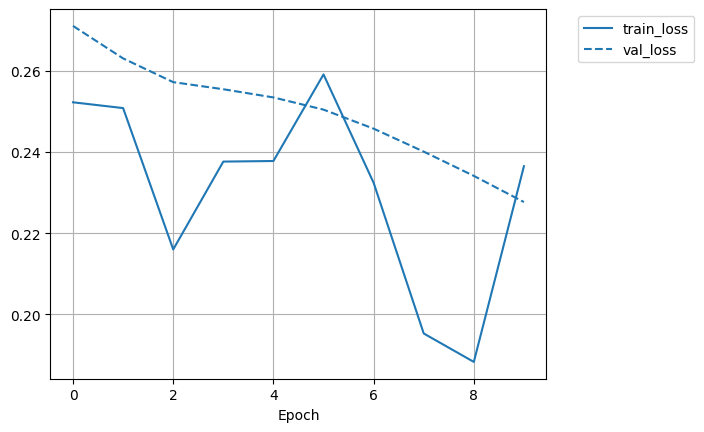

In [28]:
model.history_.plot_history(subset_term = 'loss')
# model.history_.plot_history(subset_term = 'loss')
# model.history_.plot_history(subset_term = 'r2')
# model.history_.plot_history(subset_term = 'pearson')

## 4. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [20]:
#sub_adata = adata[adata.obs['condition'] == 'SHH']

In [29]:
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm
call new
2075
103
1903
1319
1123
1100
1212
1487
2419
1143
1538
1121
172
395
967
996
546
1279
1229
167
853
1066
608
1141
1068
58
661
693
266
972
913


In [38]:
result

AnnData object with n_obs × n_vars = 30562 × 14664
    obs: 'array_row', 'array_col', 'batch', 'angio_hallmarks', 'cell_prolif', 'tumour_cells', 'nk_cells', 'macro_lam2', 'EPI', 'EMT', 'hypoxia_hallmarks_hot', 'hypoxia_hallmarks_cold', 'angio_hallmarks_hot', 'angio_hallmarks_cold', 'nk_cells_hot', 'nk_cells_cold', 'EPI_hot', 'EPI_cold', 'EPI_hot_number', 'EPI_cold_number', 'EMT_hot', 'EMT_cold', 'EMT_hot_number', 'EMT_cold_number', 'angio_hallmarks_hot_number', 'angio_hallmarks_cold_number', 'nk_cells_hot_number', 'nk_cells_cold_number', 'response_to_check_point_score', 'X', 'Y', 'sliding_window_assignment', 'globalX', 'globalY', 'split', '_scvi_sample_key_0', '_scvi_group_key', '_cls'
    uns: 'sliding_window_assignment_colors', 'spatial', 'spatial_neighbors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'MT', 'spatial', '_decoder_weight', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', '_y_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

### 4.1 Tissue level analysis

Can we detect a pattern across cells in which are more and less relevant to predict the condition? 

No cell types so need to categorize them differently. 

1. SHH expressed or not (Distance to SHH source)
2. What analysis could we perform without knowing that the SHH is the source for variation? Can we somehow trace the changes back to genes? 

In [32]:
np.unique(result.obs['sliding_window_assignment'][result.obs['split']== 'val'])

array(['0_window_0', '10_window_0', '10_window_1', '10_window_2',
       '10_window_3', '11_window_0', '1_window_0', '1_window_1',
       '1_window_2', '1_window_3', '2_window_0', '2_window_1',
       '3_window_0', '3_window_1', '3_window_2', '3_window_3',
       '4_window_0', '4_window_1', '4_window_2', '4_window_3',
       '5_window_0', '5_window_1', '5_window_2', '5_window_3',
       '6_window_0', '7_window_0', '7_window_1', '7_window_2',
       '7_window_3', '8_window_0', '9_window_0'], dtype=object)

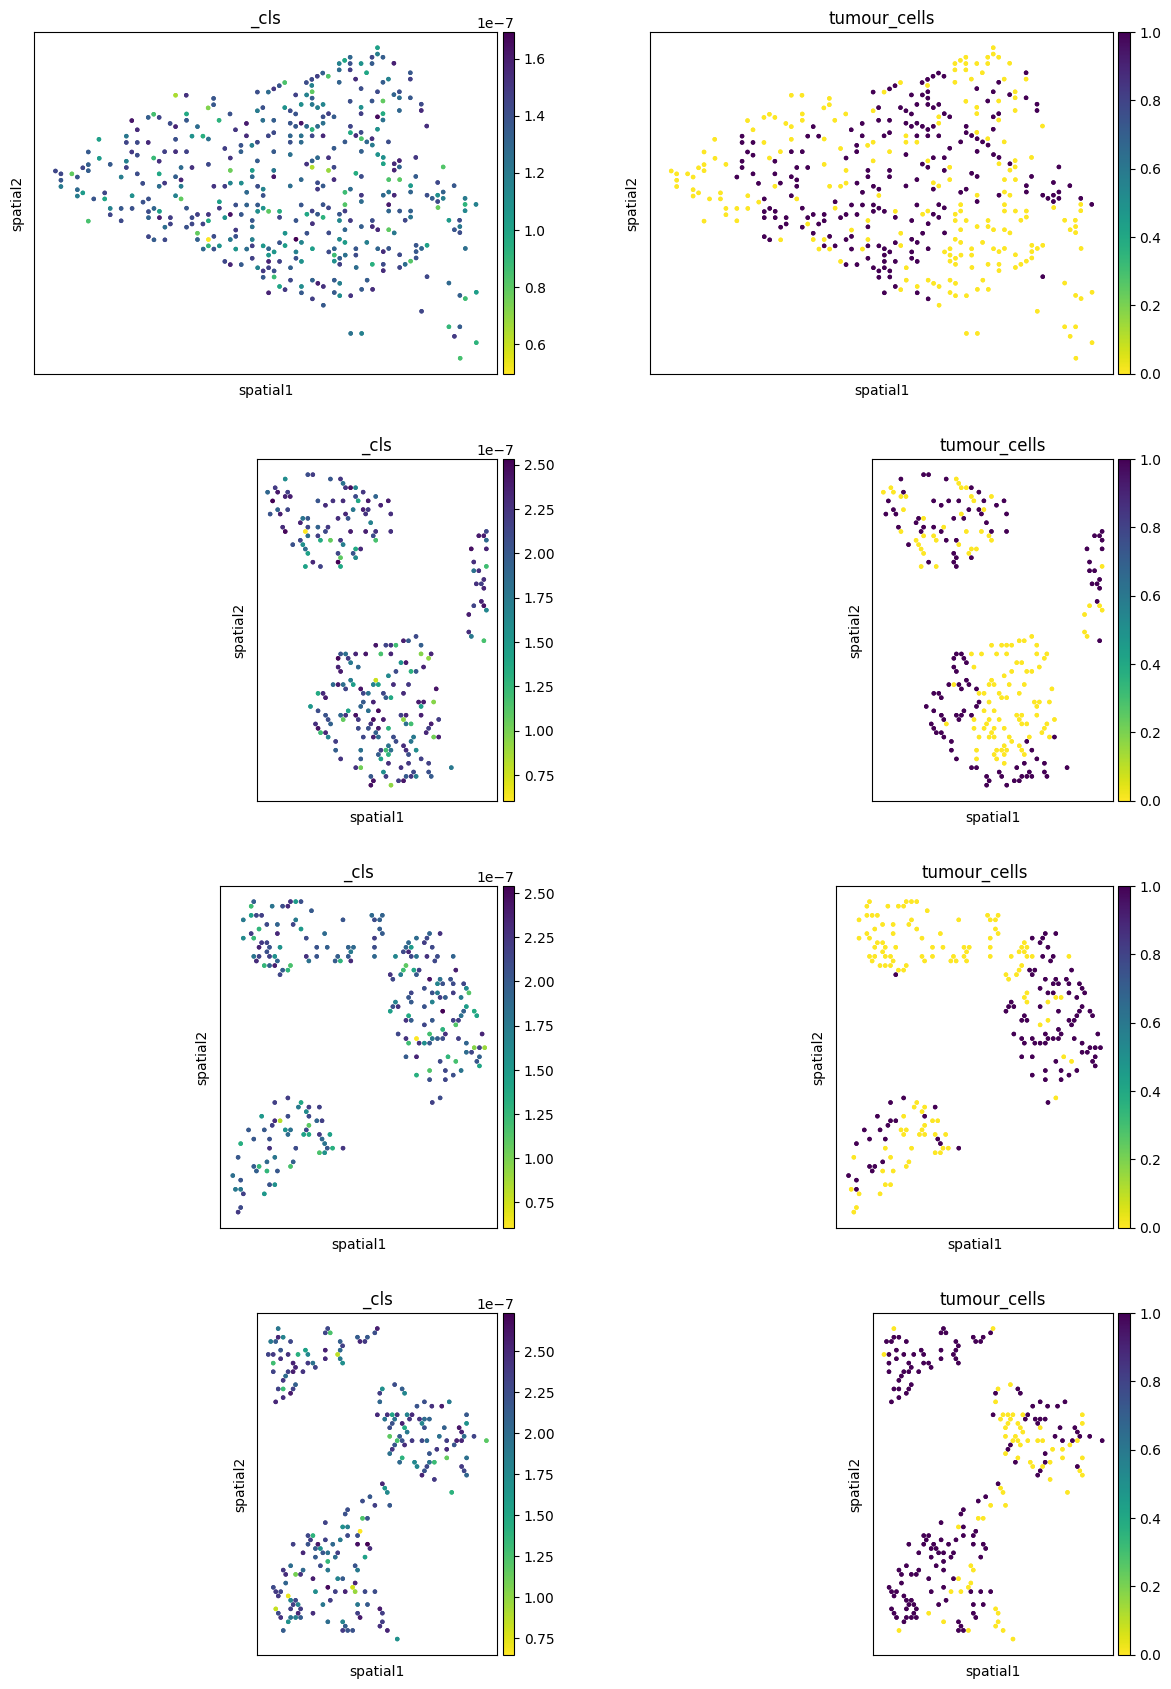

In [54]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'val'], 
                      color = ['_cls', 'tumour_cells'],
                      library_key = 'sliding_window_assignment',
                      library_id = ['0_window_0', '6_window_0', '9_window_0', '11_window_0'],
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 2,
)

/usr/local/lib/python3.10/dist-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/pyth

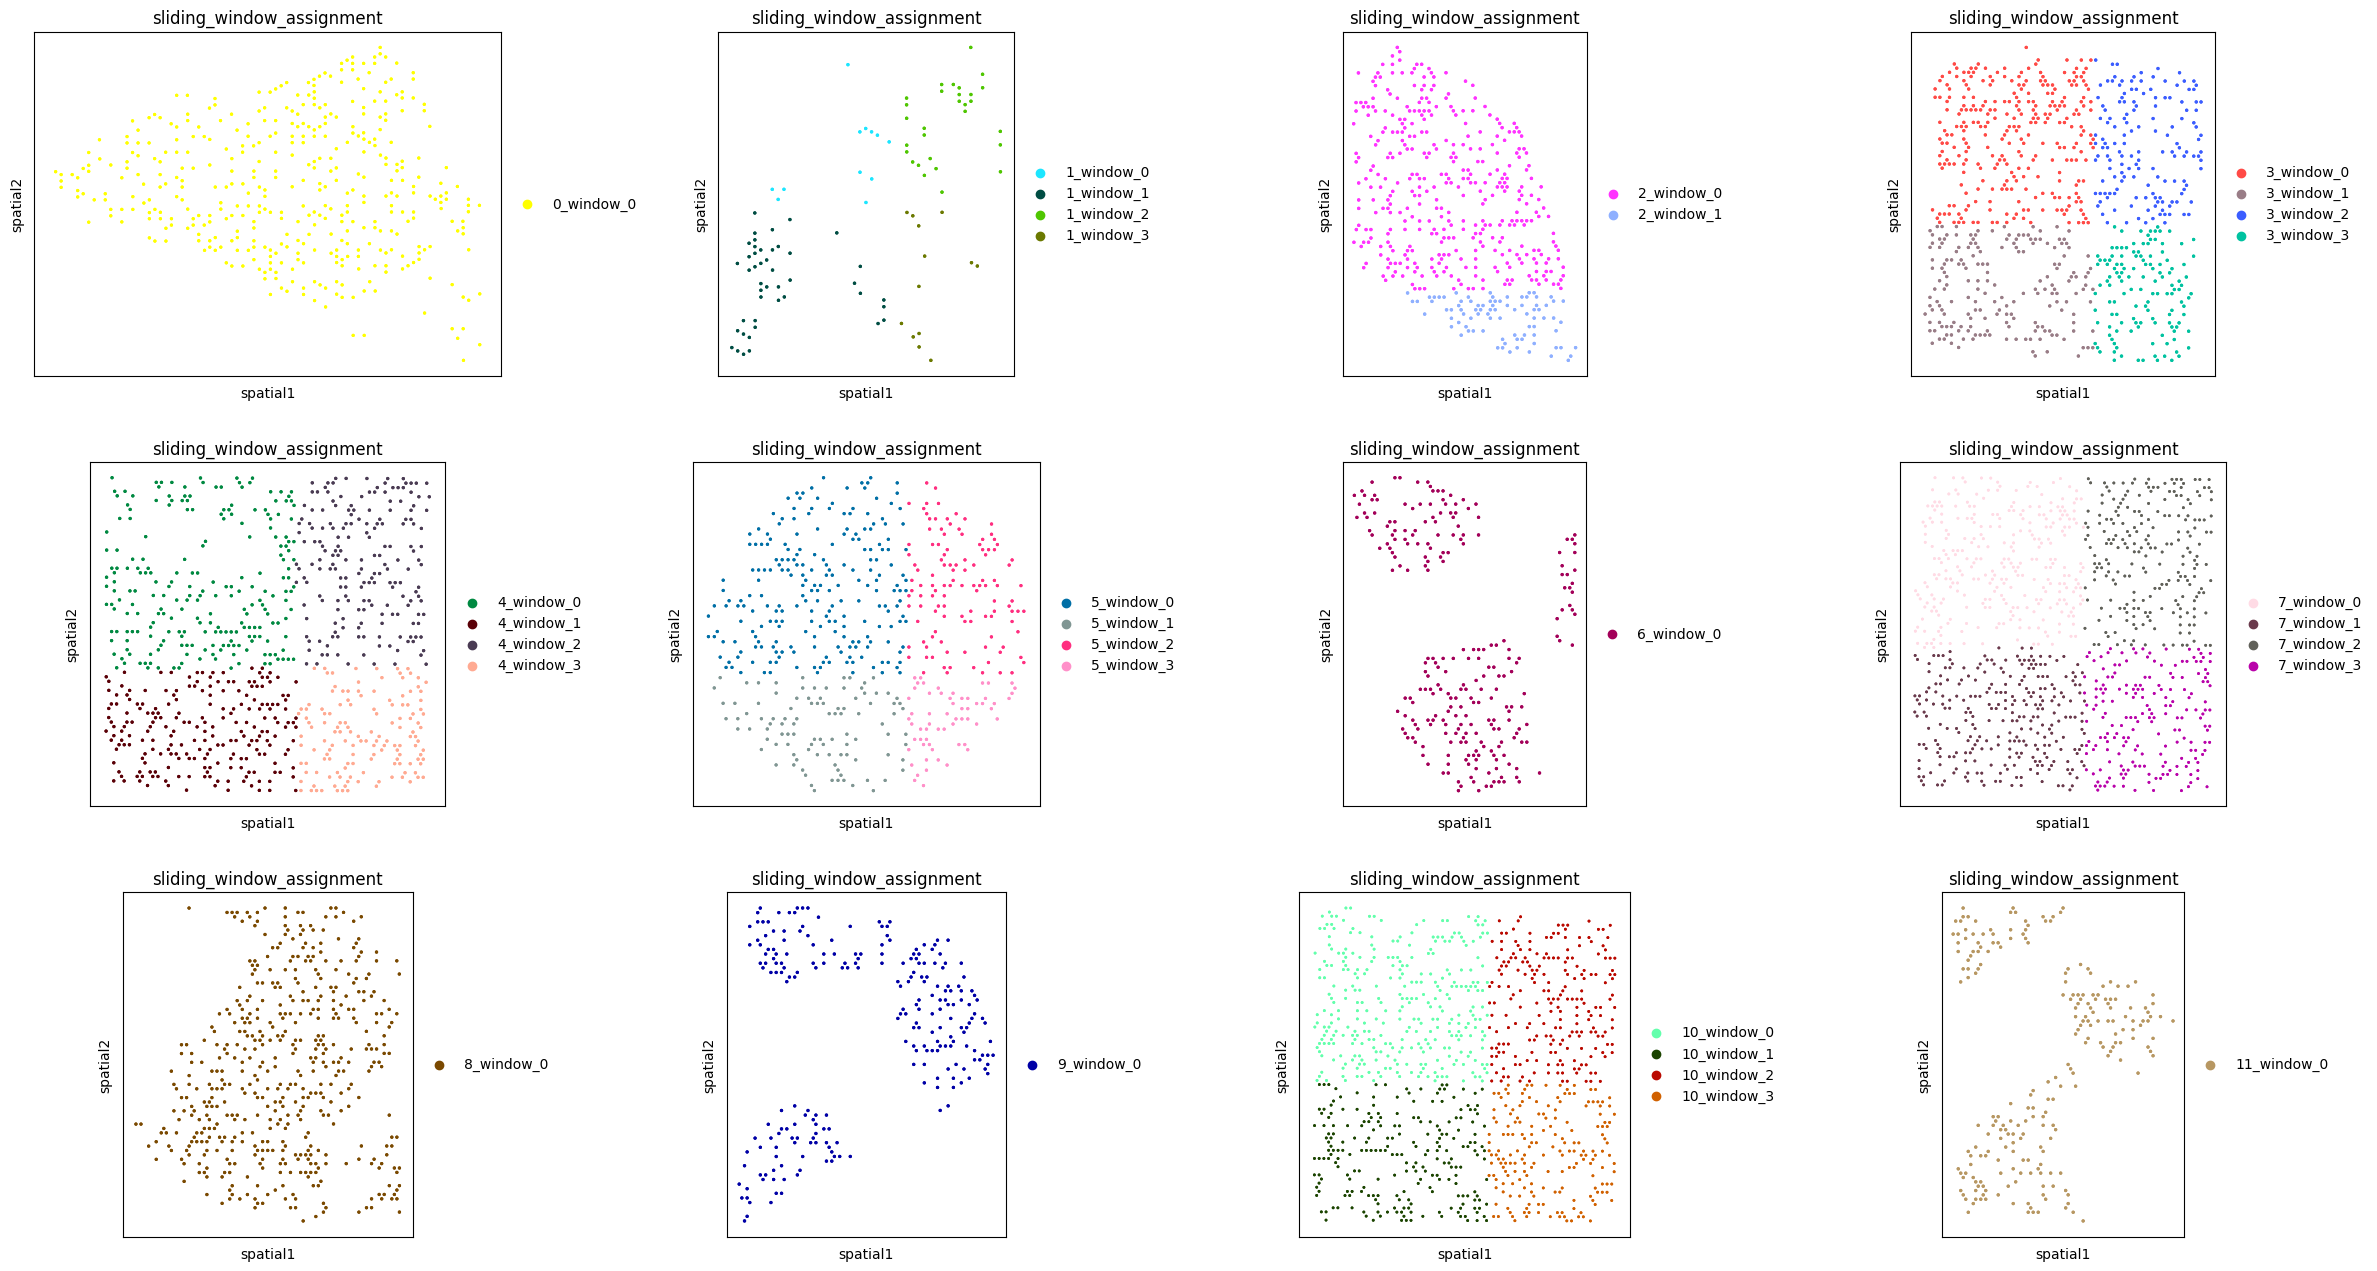

In [50]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'val'], 
                      color = ['sliding_window_assignment'],
                      library_key = 'batch',
                    cmap = 'viridis_r',
                    shape= None,
)

In [39]:
adata.obs['sample'][adata.obs['split']== 'test']

34563    slide4_A2-3
34564    slide4_A2-3
34565    slide4_A2-3
34566    slide4_A2-3
34567    slide4_A2-3
            ...     
41488    slide4_B2-2
41489    slide4_B2-2
41490    slide4_B2-2
41491    slide4_B2-2
41492    slide4_B2-2
Name: sample, Length: 3755, dtype: category
Categories (17, object): ['slide1_A2-1', 'slide1_A2-2', 'slide1_B2-1', 'slide1_B2-2', ..., 'slide4_A2-3', 'slide4_B2-1', 'slide4_B2-2', 'slide4_B2-3']

### CLS token to predict the conditions

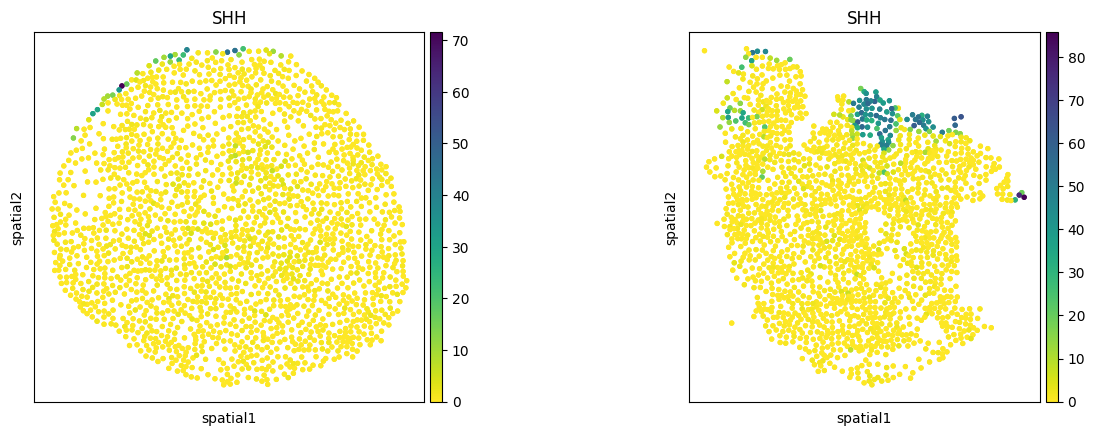

In [46]:
sq.pl.spatial_scatter(result[result.obs['split'] == 'test'], 
                      color = ['SHH'],
                      library_key = 'sample',
                    cmap = 'viridis_r',
                    shape= None,
                    #save = f'{FIG_PATH}/legnini23/legnini23_log1p_ctrl_{sample_ctrl}_SHH.jpeg'
)

In [24]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Step 1: Prepare data
X_all = np.vstack(result.obs['_cls'].values)
y_all = result.obs['condition'].values
samples_all = result.obs['sample'].values

# Drop samples with NaNs
mask = ~np.isnan(X_all).any(axis=1)
X = X_all[mask]
y = y_all[mask]
samples = samples_all[mask]

# Standardize features
X = StandardScaler().fit_transform(X)

# Step 2: Fit classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Step 3: Predict and evaluate
y_pred = clf.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Step 4: Save predictions and correctness into adata.obs
adata.obs.loc[mask, 'predicted_condition'] = y_pred
adata.obs.loc[mask, 'correct_prediction'] = (y_pred == y).astype(str)  # "True"/"False" for plotting


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 'SHH'

ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

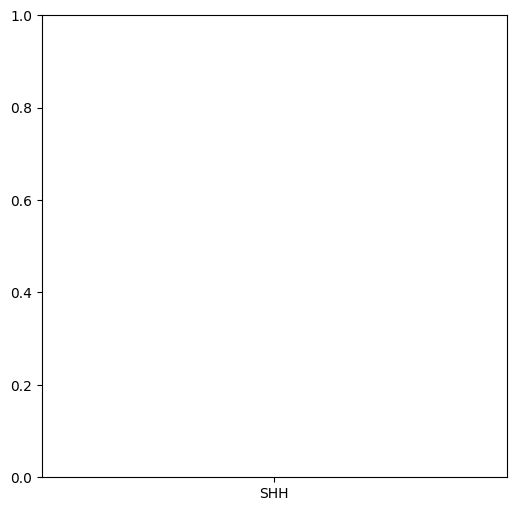

In [91]:
import matplotlib.pyplot as plt

# Suppose you have:
# coords: an (N, 2) array or DataFrame with columns ['x', 'y']
# values: a 1D array or Series with length N (values to color by)

plt.figure(figsize=(6,6))
sc = plt.scatter(y, X, color = samples, s=40)
plt.colorbar(sc, label='Value')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Spatial plot colored by 1D values')
plt.gca().invert_yaxis()  # if you want y-axis inverted (depends on data)
plt.show()


In [43]:
# plot celltype x condition 
import pandas as pd

def summarise_decoder_weight_by_group_and_condition(
    adata, 
    group_obs: str,
    condition_obs: str = '_scvi_prediction_obs', 
    decoder_weight_key: str = 'decoder_weight', 
):
    """
    Summarizes average attention weights for each (group_obs x condition_obs) combination.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object containing attention weights in adata.obsm[decoder_weight_key].
    decoder_weight_key : str
        Key for the attention weight matrix in adata.obsm.
    condition_obs : str
        Column name in adata.obs for condition (e.g., 'disease_status').
    group_obs : str
        Column name in adata.obs for group (e.g., 'cell_type').
        
    Returns
    -------
    pd.DataFrame
        Multi-index DataFrame with average attention weights for each group x condition.
        Rows: (group_obs, condition_obs)
        Columns: attention per target cell type (from decoder_weight_key).
    """
    # Extract relevant data
    weight = adata.obsm[decoder_weight_key]
    group = adata.obs[group_obs]
    condition = adata.obs[condition_obs]
    
    # Create DataFrame for easy grouping
    df = pd.DataFrame(
        weight, 
        columns=[f"{decoder_weight_key}_{i}" for i in range(weight.shape[1])]
    )
    df[group_obs] = group.values
    df[condition_obs] = condition.values
    
    # Group by group_obs and condition_obs, then average
    grouped = df.groupby([group_obs, condition_obs]).mean()
    
    return grouped

In [44]:
summarise_decoder_weight_by_group_and_condition(
    result, 
    condition_obs = 'shh_cluster', 
    group_obs = 'condition'
)

KeyError: 'shh_cluster'

In [ ]:
from scipy.stats import pearsonr
import torch
import numpy as np

y_pred_np = torch.tensor([[0.1, 0.2, 0.3],
                         [0.15, 0.25, 0.35]])
y_true_np = torch.tensor([[0.0, 0.4, 0.6],
                        [0.0, 0.34, 0.43]])

pearson_corr_raw = pearsonr(y_pred_np, y_true_np)
pearson_corr = torch.tensor(np.nanmean(pearson_corr_raw[0]), 
                                      dtype=torch.float32, 
                                      device=y_pred_np.device)

In [ ]:
pearson_corr

In [ ]:
pearson_corr_raw